In [237]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

In [238]:
sign_image_path = "./Task-1/rh_sign.jpg"
scene_image_path = "./Task-1/img5.png"

# Load images
sign_image = cv2.imread(sign_image_path, cv2.IMREAD_COLOR)
scene_image = cv2.imread(scene_image_path, cv2.IMREAD_COLOR)

In [239]:
def bgr_to_rgb(image):
   return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [240]:
def hsv_to_rgb(image):
   return cv2.cvtColor(image, cv2.COLOR_HSV2RGB)

In [241]:

def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

In [242]:
def boost_reds(image):
    # Convert to HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Split HSV channels
    h, s, v = cv2.split(hsv)

    # Target red hues (0-10 and 160-180 degrees in HSV)
    mask1 = cv2.inRange(h, 0, 10)
    mask2 = cv2.inRange(h, 160, 180)
    red_mask = cv2.bitwise_or(mask1, mask2)

    # Boost saturation for red hues
    s = cv2.addWeighted(s, 1.0, red_mask, 0.1, 0)  # Add 10% of the red mask to saturation

    # Merge channels and convert back to BGR
    boosted_hsv = cv2.merge((h, s, v))
    boosted_image = cv2.cvtColor(boosted_hsv, cv2.COLOR_HSV2BGR)

    return boosted_image


In [243]:
def boost_contrast(image):
    # Create a CLAHE object with specified clip limit and tile grid size
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    # Convert the image to LAB color space (to apply CLAHE only to the L channel)
    image_lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Split the LAB image into L, A, and B channels
    l, a, b = cv2.split(image_lab)

    # Apply CLAHE to the L channel (lightness channel)
    l_clahe = clahe.apply(l)

    # Merge the CLAHE enhanced L channel back with the A and B channels
    image_lab_clahe = cv2.merge((l_clahe, a, b))

    # Convert the image back to BGR color space
    image = cv2.cvtColor(image_lab_clahe, cv2.COLOR_LAB2BGR)

    return image

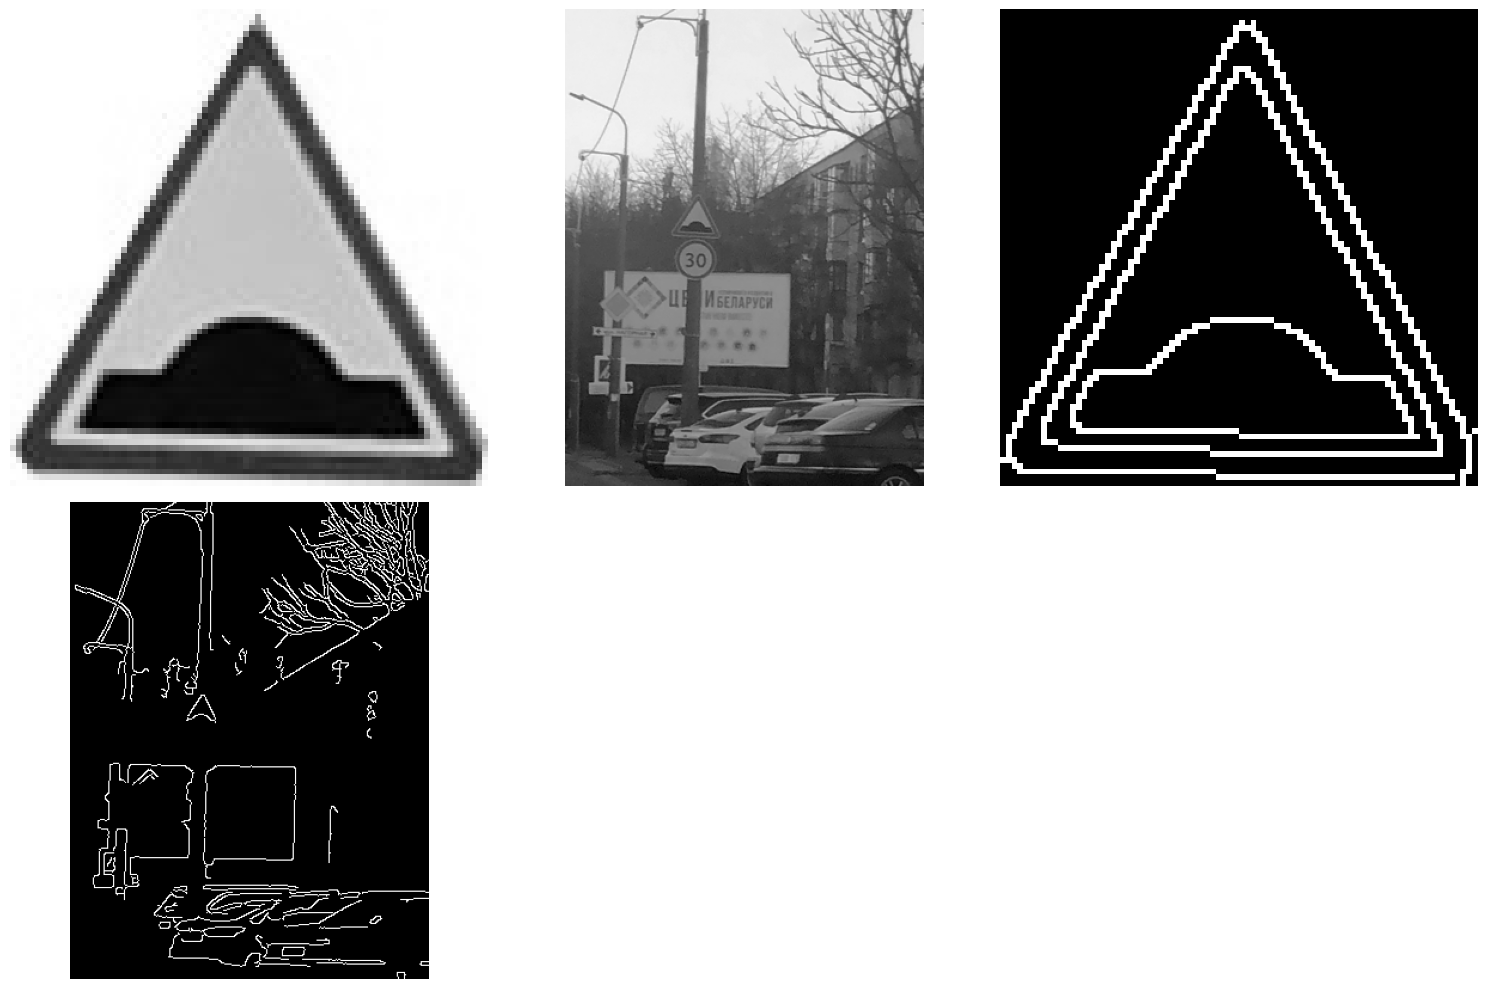

(array([[[40, 10]],

       [[40, 11]],

       [[38, 13]],

       [[38, 14]],

       [[37, 15]],

       [[37, 16]],

       [[36, 17]],

       [[36, 18]],

       [[35, 19]],

       [[35, 20]],

       [[34, 21]],

       [[34, 22]],

       [[32, 24]],

       [[32, 25]],

       [[31, 26]],

       [[31, 27]],

       [[30, 28]],

       [[30, 29]],

       [[29, 30]],

       [[29, 31]],

       [[28, 32]],

       [[28, 33]],

       [[26, 35]],

       [[26, 36]],

       [[25, 37]],

       [[25, 38]],

       [[24, 39]],

       [[24, 40]],

       [[23, 41]],

       [[23, 42]],

       [[22, 43]],

       [[22, 44]],

       [[20, 46]],

       [[20, 47]],

       [[19, 48]],

       [[19, 49]],

       [[18, 50]],

       [[18, 51]],

       [[17, 52]],

       [[17, 53]],

       [[16, 54]],

       [[16, 55]],

       [[14, 57]],

       [[14, 58]],

       [[13, 59]],

       [[13, 60]],

       [[12, 61]],

       [[12, 62]],

       [[10, 64]],

       [[10, 65]],


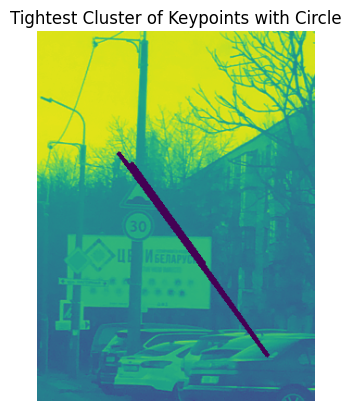

In [244]:
def preprocess_with_edges(image):
    """Preprocess the image using edge detection."""
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    edges = cv2.Canny(blurred, 70, 150)  # Edge detection
    return edges

def is_triangle(contour):
    """Check if a contour is a triangle based on vertex count and other properties."""
    # Approximate the contour to a polygon
    epsilon = 0.04 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    # Check if the shape has 3 vertices
    if len(approx) == 3:
        # Check aspect ratio (optional, adjust as needed)
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / h
        if 0.8 < aspect_ratio < 1.2:  # Close to equilateral triangle
            return True
    return False

def extract_red_contour(image):
    """Detect and extract red contours in the image."""
    # Convert to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define the range for red color in HSV space
    lower_red = np.array([0, 120, 70])
    upper_red = np.array([10, 255, 255])
    red_mask1 = cv2.inRange(hsv, lower_red, upper_red)

    lower_red = np.array([170, 120, 70])
    upper_red = np.array([180, 255, 255])
    red_mask2 = cv2.inRange(hsv, lower_red, upper_red)

    # Combine the two masks for red color
    red_mask = cv2.bitwise_or(red_mask1, red_mask2)
    red_region = cv2.bitwise_and(image, image, mask=red_mask)

    return red_region, red_mask



# Load the reference and search images
reference_image = cv2.cvtColor(cv2.imread(sign_image_path), cv2.COLOR_BGR2GRAY)
search_image = cv2.cvtColor(cv2.imread(scene_image_path), cv2.COLOR_BGR2GRAY)

# Step 1: Detect edges in both images
reference_edges = preprocess_with_edges(reference_image)
search_edges = preprocess_with_edges(search_image)

# Step 2: Find contours in the search image
reference_contours, _ = cv2.findContours(reference_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
search_contours, _ = cv2.findContours(search_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

plot_images([reference_image, search_image, reference_edges, search_edges])

print(reference_contours)
# # Step 4: Apply SIFT feature matching
sift = cv2.SIFT_create()

# # Detect keypoints and descriptors in the reference and search images
keypoints_ref, descriptors_ref = sift.detectAndCompute(reference_image, None)
keypoints_search, descriptors_search = sift.detectAndCompute(search_image, None)

# # Use BFMatcher to match the descriptors
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(descriptors_ref, descriptors_search)

# # Sort the matches by distance
matches = sorted(matches, key=lambda x: x.distance)

# # Draw the matches on a new image
result = cv2.drawMatches(reference_image, keypoints_ref, search_image, keypoints_search, matches[:20], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Extract points from the matches
src_pts = np.float32([keypoints_ref[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
dst_pts = np.float32([keypoints_search[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

H, _ = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

print("H", H)

height, width = reference_image.shape[:2]

# Define the corners of the reference image
corners = np.array([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
], dtype='float32')

corners = corners.reshape(-1, 1, 2)

# Apply the homography to the corners
transformed_corners = cv2.perspectiveTransform(corners, H)

# Draw the bounding box on the search image
result = cv2.polylines(search_image, [np.int32(transformed_corners)], isClosed=True, color=(0, 255, 0), thickness=3)

# Show the result
plt.imshow(result)
plt.title('Tightest Cluster of Keypoints with Circle')
plt.axis('off')
plt.show()


In [245]:
locate_rh_sign(sign_image, scene_image)

NameError: name 'locate_rh_sign' is not defined